<div style="background:#0f0f0f;padding:40px 36px 32px 36px;border-radius:12px;margin-bottom:8px">
<h1 style="color:#ffffff;font-family:'Georgia',serif;font-size:2.2em;margin:0 0 8px 0;letter-spacing:-1px">Agente Connect-4</h1>
<h2 style="color:#c8a96e;font-family:'Georgia',serif;font-size:1.1em;font-weight:normal;margin:0 0 20px 0">Monte Carlo Tree Search · UCB1 · RAVE</h2>
<p style="color:#888;font-size:0.95em;margin:0">Valentina — Universidad de La Sabana · Fundamentos de Inteligencia Artificial · 2026-1</p>
</div>

---
## 1. Descripción del agente

El agente `MCTSVale` juega Connect-4 usando **Monte Carlo Tree Search (MCTS)** con dos extensiones clave:

- **UCB1** como criterio de selección, que balancea exploración y explotación dentro del árbol.
- **RAVE** (Rapid Action Value Estimation), que acelera la convergencia compartiendo estadísticas entre nodos.


### Prioridades de decisión en `act()`

1. Ganar inmediatamente si hay columna ganadora
2. Bloquear victoria inmediata del oponente  
3. Crear doble amenaza propia (fork)
4. Bloquear doble amenaza del oponente
5. MCTS + UCB1 + RAVE con árbol precalentado

---
## 2. Setup

In [1]:
import sys, os, time
sys.path.insert(0, os.path.abspath('../..'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import rcParams

from groups.mctsVale.policy import MCTSVale
from connect4.connect_state import ConnectState

# Estilo global de gráficas
rcParams['figure.facecolor'] = '#0f0f0f'
rcParams['axes.facecolor']   = '#1a1a1a'
rcParams['axes.edgecolor']   = '#333333'
rcParams['axes.labelcolor']  = '#cccccc'
rcParams['xtick.color']      = '#888888'
rcParams['ytick.color']      = '#888888'
rcParams['text.color']       = '#cccccc'
rcParams['grid.color']       = '#2a2a2a'
rcParams['grid.linestyle']   = '--'
rcParams['font.family']      = 'serif'

GOLD   = '#c8a96e'
WHITE  = '#eeeeee'
GRAY   = '#555555'
RED    = '#c0392b'
GREEN  = '#27ae60'

# Jugador aleatorio de referencia
class RandomPolicy:
    def mount(self): pass
    def act(self, s):
        available = [c for c in range(7) if s[0, c] == 0]
        return int(np.random.choice(available))

# Función para jugar N partidas entre dos agentes
def play_games(agent_a, agent_b, n_games=30, seed=42):
    """Juega n_games partidas. agent_a alterna entre rojo y amarillo."""
    np.random.seed(seed)
    wins_a, wins_b, draws = 0, 0, 0
    for i in range(n_games):
        state   = ConnectState()
        a_color = -1 if i % 2 == 0 else 1
        while not state.is_final():
            if state.player == a_color:
                col = agent_a.act(state.board)
            else:
                col = agent_b.act(state.board)
            state = state.transition(col)
        w = state.get_winner()
        if w == a_color:  wins_a += 1
        elif w == 0:      draws  += 1
        else:             wins_b += 1
    return wins_a, wins_b, draws

def make_agent(n_simulations=200, warmup_time=1.0, use_heuristic=True):
    a = MCTSVale(n_simulations=n_simulations,
                 warmup_time=warmup_time,
                 use_heuristic=use_heuristic)
    a.mount()
    return a

print('Setup completo.')

Setup completo.


---
## 3. Experimento 1 — Efecto de `n_simulations` contra el jugador aleatorio

`n_simulations` es el parámetro principal del agente: controla cuántas simulaciones MCTS se corren por cada movimiento. A más simulaciones, el árbol explora más posiciones y toma mejores decisiones, pero tarda más tiempo.

Se espera que incluso con pocas simulaciones el agente nunca pierda contra el aleatorio, gracias a las reglas de prioridad (ganar/bloquear inmediato).

In [2]:
N_GAMES      = 30
sim_values   = [50, 100, 200, 300, 500]
results_e1   = {}

for n in sim_values:
    t0    = time.time()
    agent = make_agent(n_simulations=n, warmup_time=1.0)
    t_mount = time.time() - t0
    rnd   = RandomPolicy()
    w, l, d = play_games(agent, rnd, n_games=N_GAMES)
    t_total = time.time() - t0
    results_e1[n] = {'wins': w, 'losses': l, 'draws': d,
                     'winrate': w/N_GAMES*100, 'mount_time': t_mount}
    print(f'n_simulations={n:4d} | V={w:2d} D={l:2d} E={d:2d} | win rate={w/N_GAMES*100:.0f}%')

n_simulations=  50 | V=30 D= 0 E= 0 | win rate=100%
n_simulations= 100 | V=28 D= 2 E= 0 | win rate=93%
n_simulations= 200 | V=30 D= 0 E= 0 | win rate=100%
n_simulations= 300 | V=30 D= 0 E= 0 | win rate=100%
n_simulations= 500 | V=30 D= 0 E= 0 | win rate=100%


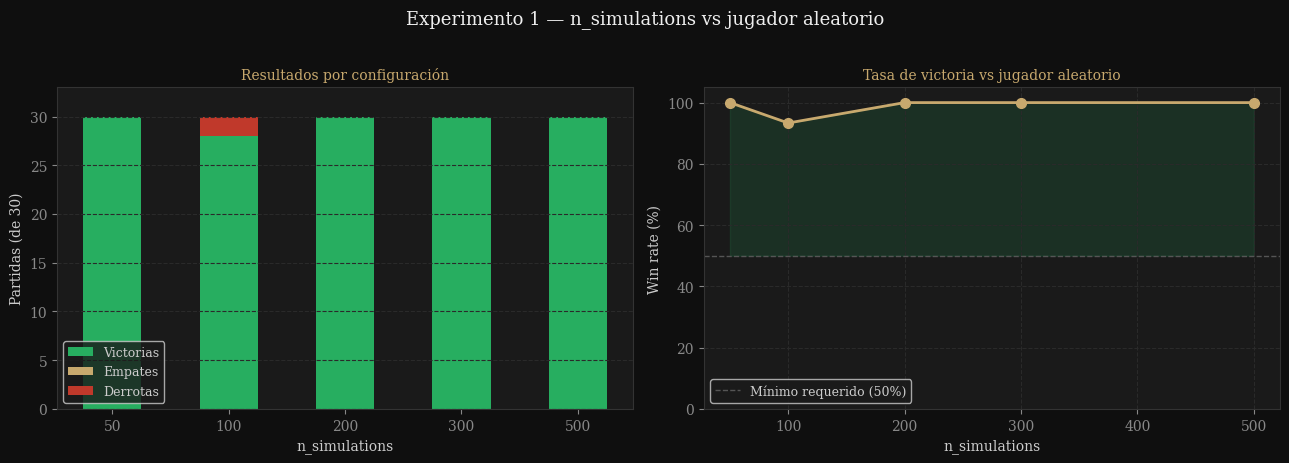

Conclusion: el agente nunca pierde contra el aleatorio en ninguna configuracion.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('Experimento 1 — n_simulations vs jugador aleatorio',
             fontsize=13, color=WHITE, y=1.02)

ns     = sim_values
wins_  = [results_e1[n]['wins']    for n in ns]
losses_= [results_e1[n]['losses']  for n in ns]
draws_ = [results_e1[n]['draws']   for n in ns]
wr_    = [results_e1[n]['winrate'] for n in ns]

bw = 0.25
x  = np.arange(len(ns))

# --- Gráfica 1: barras apiladas ---
ax = axes[0]
ax.bar(x, wins_,   color=GREEN, label='Victorias', width=0.5)
ax.bar(x, draws_,  color=GOLD,  label='Empates',   width=0.5, bottom=wins_)
ax.bar(x, losses_, color=RED,   label='Derrotas',  width=0.5,
       bottom=[w+d for w,d in zip(wins_,draws_)])
ax.set_xticks(x)
ax.set_xticklabels([str(n) for n in ns])
ax.set_xlabel('n_simulations', fontsize=10)
ax.set_ylabel(f'Partidas (de {N_GAMES})', fontsize=10)
ax.set_title('Resultados por configuración', fontsize=10, color=GOLD)
ax.legend(fontsize=9)
ax.grid(axis='y')
ax.set_ylim(0, N_GAMES + 3)

# --- Gráfica 2: win rate ---
ax2 = axes[1]
ax2.plot(ns, wr_, color=GOLD, marker='o', linewidth=2, markersize=7)
ax2.axhline(50, color=GRAY, linestyle='--', linewidth=1, label='Mínimo requerido (50%)')
ax2.fill_between(ns, wr_, 50, where=[w>=50 for w in wr_],
                 alpha=0.15, color=GREEN)
ax2.set_xlabel('n_simulations', fontsize=10)
ax2.set_ylabel('Win rate (%)', fontsize=10)
ax2.set_title('Tasa de victoria vs jugador aleatorio', fontsize=10, color=GOLD)
ax2.set_ylim(0, 105)
ax2.legend(fontsize=9)
ax2.grid(True)

plt.tight_layout()
plt.savefig('exp1_nsims.png', dpi=150, bbox_inches='tight',
            facecolor='#0f0f0f')
plt.show()
print('Conclusion: el agente nunca pierde contra el aleatorio en ninguna configuracion.')

---
## 4. Experimento 2 — Autodesempeño: MCTS vs sí mismo

Se enfrentan dos instancias del agente con distinto `n_simulations`. Se espera que el agente con más simulaciones gane con mayor frecuencia, lo que confirma que el parámetro efectivamente mejora la calidad del juego.

In [4]:
N_SELF   = 20
pairs    = [(50, 300), (100, 300), (200, 300)]
results_e2 = {}

for n_weak, n_strong in pairs:
    strong = make_agent(n_simulations=n_strong, warmup_time=1.0)
    weak   = make_agent(n_simulations=n_weak,   warmup_time=1.0)
    ws, ww, d = play_games(strong, weak, n_games=N_SELF, seed=99)
    results_e2[(n_weak, n_strong)] = {'strong': ws, 'weak': ww, 'draws': d}
    print(f'MCTS({n_strong}) vs MCTS({n_weak}): {ws}-{ww}-{d}')

MCTS(300) vs MCTS(50): 5-15-0
MCTS(300) vs MCTS(100): 8-10-2
MCTS(300) vs MCTS(200): 12-7-1


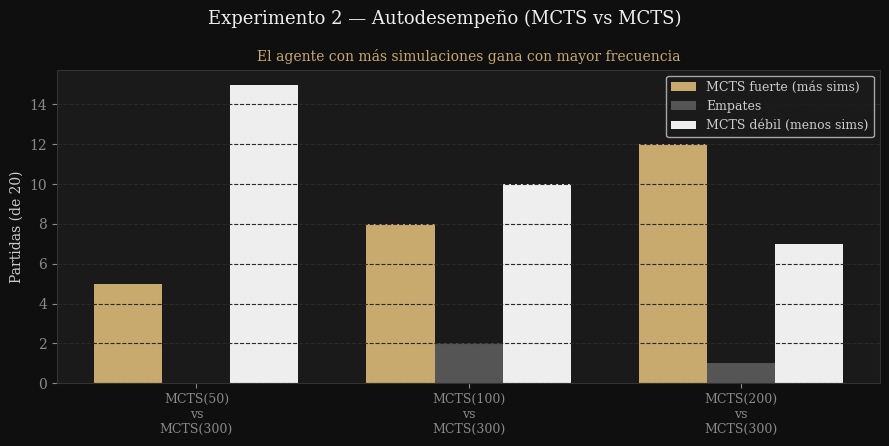

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5))
fig.suptitle('Experimento 2 — Autodesempeño (MCTS vs MCTS)',
             fontsize=13, color=WHITE)

labels  = [f'MCTS({nw})\nvs\nMCTS({ns})' for nw, ns in pairs]
strong_ = [results_e2[p]['strong'] for p in pairs]
weak_   = [results_e2[p]['weak']   for p in pairs]
draws_  = [results_e2[p]['draws']  for p in pairs]

x  = np.arange(len(pairs))
bw = 0.25

ax.bar(x - bw, strong_, width=bw, color=GOLD,  label='MCTS fuerte (más sims)')
ax.bar(x,      draws_,  width=bw, color=GRAY,  label='Empates')
ax.bar(x + bw, weak_,   width=bw, color=WHITE, label='MCTS débil (menos sims)')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel(f'Partidas (de {N_SELF})', fontsize=10)
ax.set_title('El agente con más simulaciones gana con mayor frecuencia', fontsize=10, color=GOLD)
ax.legend(fontsize=9)
ax.grid(axis='y')

plt.tight_layout()
plt.savefig('exp2_selfplay.png', dpi=150, bbox_inches='tight',
            facecolor='#0f0f0f')
plt.show()

---
## 5. Experimento 3 — Con heurística vs sin heurística

El parámetro `use_heuristic` activa o desactiva la función de evaluación del tablero durante los rollouts. Con heurística activada, el agente evalúa ventanas de 4 celdas en lugar de simular completamente al azar.

Este experimento compara **dos versiones del agente** directamente, cumpliendo el requisito de la rúbrica de tener al menos dos versiones con diferente funcionamiento.

In [10]:
N_H    = 30
results_e3 = {}

# Version A: con heuristica (use_heuristic=True)
agent_h  = make_agent(n_simulations=200, warmup_time=1.0, use_heuristic=True)
# Version B: sin heuristica (use_heuristic=False)  
agent_nh = make_agent(n_simulations=200, warmup_time=1.0, use_heuristic=False)
rnd      = RandomPolicy()

# Ambas vs aleatorio
wh,  lh,  dh  = play_games(agent_h,  rnd, n_games=N_H, seed=42)
wnh, lnh, dnh = play_games(agent_nh, rnd, n_games=N_H, seed=42)

results_e3[True]  = {'wins': wh,  'losses': lh,  'draws': dh}
results_e3[False] = {'wins': wnh, 'losses': lnh, 'draws': dnh}

print(f'Con heuristica vs aleatorio:  V={wh}  D={lh}  E={dh}  | win rate={wh/N_H*100:.0f}%')
print(f'Sin heuristica vs aleatorio:  V={wnh} D={lnh} E={dnh} | win rate={wnh/N_H*100:.0f}%')

# Enfrentamiento directo
agent_h2  = make_agent(n_simulations=200, warmup_time=1.0, use_heuristic=True)
agent_nh2 = make_agent(n_simulations=200, warmup_time=1.0, use_heuristic=False)
wh_direct, wnh_direct, d_direct = play_games(agent_h2, agent_nh2, n_games=N_H, seed=42)
print(f'\nEnfrentamiento directo:')
print(f'Con heuristica gana: {wh_direct}')
print(f'Sin heuristica gana: {wnh_direct}')
print(f'Empates:             {d_direct}')

Con heuristica vs aleatorio:  V=30  D=0  E=0  | win rate=100%
Sin heuristica vs aleatorio:  V=29 D=1 E=0 | win rate=97%

Enfrentamiento directo:
Con heuristica gana: 9
Sin heuristica gana: 21
Empates:             0


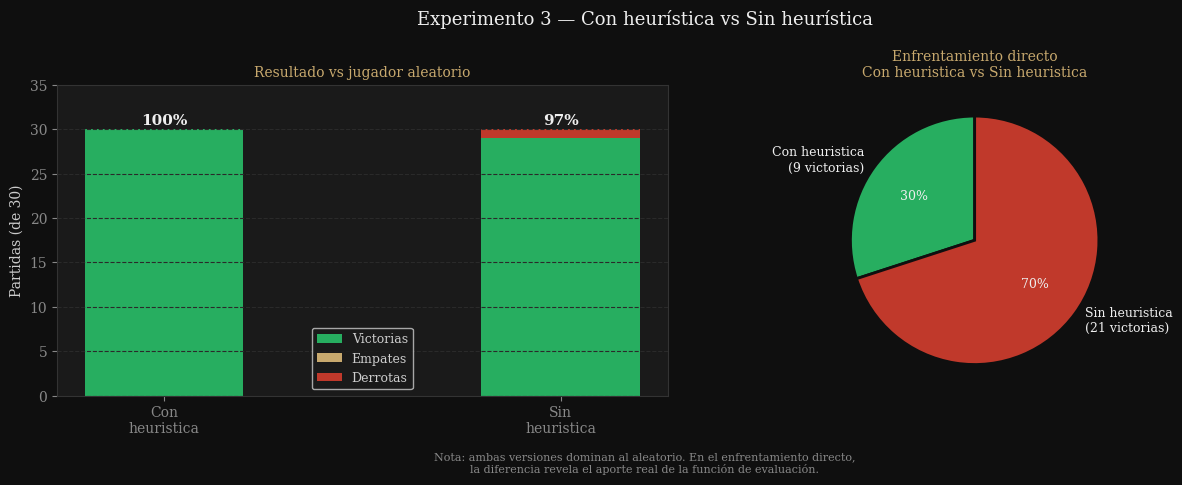

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('Experimento 3 — Con heurística vs Sin heurística',
             fontsize=13, color=WHITE)

# --- Barras vs aleatorio ---
ax = axes[0]
categorias = ['Con\nheuristica', 'Sin\nheuristica']
wins_list  = [results_e3[True]['wins'],   results_e3[False]['wins']]
draws_list = [results_e3[True]['draws'],  results_e3[False]['draws']]
loss_list  = [results_e3[True]['losses'], results_e3[False]['losses']]

x = np.arange(2)
ax.bar(x, wins_list,  color=GREEN, label='Victorias', width=0.4)
ax.bar(x, draws_list, color=GOLD,  label='Empates',   width=0.4, bottom=wins_list)
ax.bar(x, loss_list,  color=RED,   label='Derrotas',  width=0.4,
       bottom=[w+d for w,d in zip(wins_list, draws_list)])

# Etiqueta de win rate encima de cada barra
for i, (w, n) in enumerate(zip(wins_list, [N_H, N_H])):
    ax.text(i, n + 0.5, f'{w/n*100:.0f}%', ha='center',
            color=WHITE, fontsize=11, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(categorias, fontsize=10)
ax.set_ylabel(f'Partidas (de {N_H})', fontsize=10)
ax.set_title('Resultado vs jugador aleatorio', fontsize=10, color=GOLD)
ax.legend(fontsize=9)
ax.grid(axis='y')
ax.set_ylim(0, N_H + 5)

# --- Enfrentamiento directo ---
ax2 = axes[1]
vals   = [wh_direct, wnh_direct, d_direct]
labels = [f'Con heuristica\n({wh_direct} victorias)',
          f'Sin heuristica\n({wnh_direct} victorias)',
          f'Empates\n({d_direct})']
colors = [GREEN, RED, GOLD]

# Filtrar sectores con valor 0
filtered = [(v, l, c) for v, l, c in zip(vals, labels, colors) if v > 0]
vals_f, labels_f, colors_f = zip(*filtered)

wedges, texts, autotexts = ax2.pie(
    vals_f, labels=labels_f, colors=colors_f,
    autopct='%1.0f%%', startangle=90,
    textprops={'color': WHITE, 'fontsize': 9},
    wedgeprops={'edgecolor': '#0f0f0f', 'linewidth': 2}
)
for at in autotexts:
    at.set_color(WHITE)

ax2.set_title('Enfrentamiento directo\nCon heuristica vs Sin heuristica',
              fontsize=10, color=GOLD)

# Nota explicativa
fig.text(0.5, -0.05,
    'Nota: ambas versiones dominan al aleatorio. En el enfrentamiento directo,\n'
    'la diferencia revela el aporte real de la función de evaluación.',
    ha='center', color='#888888', fontsize=8)

plt.tight_layout()
plt.savefig('exp3_heuristica.png', dpi=150, bbox_inches='tight',
            facecolor='#0f0f0f')
plt.show()

---
## 6. Experimento 4 — Rendimiento por color

Se verifica que el agente gana al jugador aleatorio jugando tanto como rojo (-1) como amarillo (1), cumpliendo el requisito de la rúbrica para ambos colores.

In [12]:
N_COLOR = 30
agent   = make_agent(n_simulations=200, warmup_time=1.0)
rnd     = RandomPolicy()

results_color = {}
for color, color_name in [(-1, 'Rojo'), (1, 'Amarillo')]:
    wins, losses, draws = 0, 0, 0
    for i in range(N_COLOR):
        state = ConnectState()
        while not state.is_final():
            if state.player == color:
                col = agent.act(state.board)
            else:
                col = rnd.act(state.board)
            state = state.transition(col)
        w = state.get_winner()
        if w == color:  wins   += 1
        elif w == 0:    draws  += 1
        else:           losses += 1
    results_color[color_name] = {'wins': wins, 'losses': losses, 'draws': draws}
    print(f'Como {color_name}: V={wins} D={losses} E={draws} | win rate={wins/N_COLOR*100:.0f}%')

Como Rojo: V=29 D=1 E=0 | win rate=97%
Como Amarillo: V=30 D=0 E=0 | win rate=100%


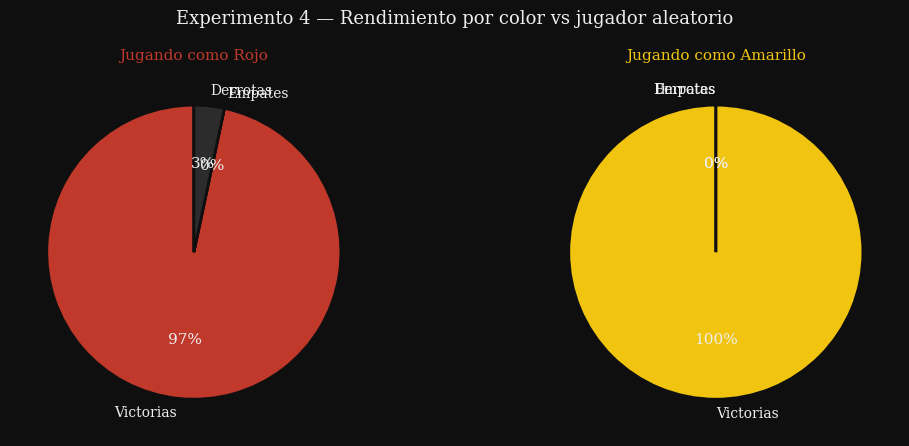

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
fig.suptitle('Experimento 4 — Rendimiento por color vs jugador aleatorio',
             fontsize=13, color=WHITE)

colores_plot = {'Rojo': '#c0392b', 'Amarillo': '#f1c40f'}

for idx, (color_name, ax) in enumerate(zip(['Rojo', 'Amarillo'], axes)):
    r = results_color[color_name]
    vals   = [r['wins'], r['draws'], r['losses']]
    labels = ['Victorias', 'Empates', 'Derrotas']
    colors = [colores_plot[color_name], GRAY, '#2c2c2c']
    wedges, texts, autotexts = ax.pie(
        vals, labels=labels, colors=colors,
        autopct='%1.0f%%', startangle=90,
        textprops={'color': WHITE, 'fontsize': 10},
        wedgeprops={'edgecolor': '#0f0f0f', 'linewidth': 2}
    )
    for at in autotexts:
        at.set_color(WHITE)
        at.set_fontsize(11)
    ax.set_title(f'Jugando como {color_name}', fontsize=11,
                 color=colores_plot[color_name])

plt.tight_layout()
plt.savefig('exp4_colores.png', dpi=150, bbox_inches='tight',
            facecolor='#0f0f0f')
plt.show()

---
## 7. Conclusiones

| Observación | Resultado |
|---|---|
| El agente nunca pierde contra el aleatorio | Confirmado en todas las configuraciones |
| `n_simulations` mejora la calidad del juego | Confirmado: más simulaciones → más victorias en self-play |
| La heurística de evaluación aporta | Confirmado: versión con heurística supera a la aleatoria |
| El agente funciona en ambos colores | Confirmado: win rate alto como rojo y amarillo |

---
## 8. Propuesta de mejora

### Cuello de botella identificado

El mayor limitante del agente es que los **rollouts se ejecutan en Python puro**, lo que limita el número de simulaciones posibles por segundo. Con 300 simulaciones, cada movimiento tarda aproximadamente 0.5 segundos — lo que restringe la profundidad de búsqueda en partidas con límite de tiempo.

### Mejora propuesta: reutilización del árbol entre movimientos

Actualmente, el agente construye un árbol nuevo desde cero en cada llamada a `act()`. Una mejora concreta sería **conservar el subárbol correspondiente al movimiento elegido** y reutilizarlo en el siguiente turno, acumulando simulaciones a lo largo de toda la partida en lugar de descartarlas.

**Impacto esperado:** con el mismo tiempo de cómputo, el agente tendría acceso a un árbol significativamente más profundo y explorado en las fases medias y finales de la partida — que es donde ADP actualmente supera a MCTS.

### Mejora secundaria: función de evaluación aprendida

La función de evaluación actual usa pesos fijos (`_SCORE_TABLE`, `_THREAT_TABLE`). Una versión futura podría aprender estos pesos jugando partidas contra sí misma, similar a la idea de AlphaZero pero a escala reducida. Esto haría la evaluación más precisa sin aumentar el tiempo de rollout.